In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/zekhe/Downloads/HealthConnect_Appointment_Data.csv")

In [3]:
df.info

<bound method DataFrame.info of      appointment_id patient_id  gender  age age_group  \
0          HC-00001     P-1613  Female   39     35-44   
1          HC-00002     P-0813    Male   31     25-34   
2          HC-00003     P-1366  Female   50     45-54   
3          HC-00004     P-1031    Male   59     55-64   
4          HC-00005     P-1458  Female   34     25-34   
...             ...        ...     ...  ...       ...   
4995       HC-04996     P-0007    Male   49     45-54   
4996       HC-04997     P-1501  Female   52     45-54   
4997       HC-04998     P-0315    Male   59     55-64   
4998       HC-04999     P-1262    Male   47     45-54   
4999       HC-05000     P-1793  Female   19     18-24   

             appointment_type booking_date appointment_date appointment_day  \
0                   Follow-up     2/6/2025        2/18/2025         Tuesday   
1     Specialist Consultation    2/25/2026        2/27/2026          Friday   
2        General Consultation   11/16/2025    

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   str    
 1   patient_id             5000 non-null   str    
 2   gender                 5000 non-null   str    
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   str    
 5   appointment_type       5000 non-null   str    
 6   booking_date           5000 non-null   str    
 7   appointment_date       5000 non-null   str    
 8   appointment_day        5000 non-null   str    
 9   appointment_time       5000 non-null   str    
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   str    
 14  reminder_channel       3634 non-null   str    
 15  distance_to_cli

In [11]:
df.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


## DATA CLEANING

In [4]:
((df.appointment_id).duplicated()).sum()

np.int64(0)

In [6]:
df["reminder_channel"] = df["reminder_channel"].fillna("No Reminder")

In [7]:
dist_ave = df["distance_to_clinic_km"].mean()

In [8]:
df["distance_to_clinic_km"] = df["distance_to_clinic_km"].fillna(dist_ave)

In [9]:
time_ave = df["waiting_time_minutes"].mean()

In [10]:
df["waiting_time_minutes"] = df["waiting_time_minutes"].fillna(time_ave)

## KPIs

In [51]:
(df.appointment_outcome == "No-Show").sum()/len(df)*100 ###No-Show Rate

np.float64(48.46)

In [53]:
(df.appointment_outcome == "Attended").sum()/len(df)*100 ###Attendance Rate

np.float64(46.28)

In [63]:
count2 = df["appointment_outcome"].value_counts()
count2

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

In [64]:
labels2 = ["No-Show", "Attended", "Cancelled"]

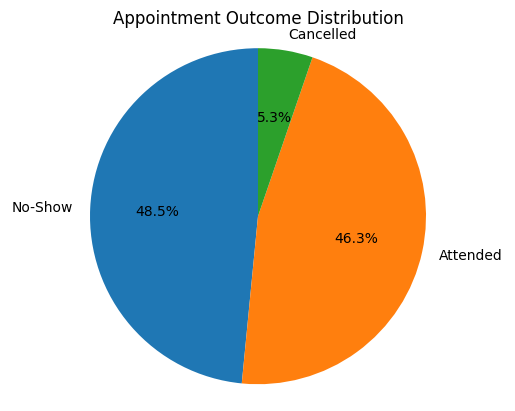

In [65]:
plt.pie(count2, labels = labels2, autopct='%1.1f%%', startangle=90)
plt.title("Appointment Outcome Distribution")
plt.axis('equal') 
plt.show()

In [54]:
bins = [0, 5, 10, 20, 30, 40, 50]

In [55]:
label = ["0-5 km", "5-10 km", "10-20 km", "20-30 km", "30-40 km", "40-50 km"]

In [56]:
df['distance_group'] = pd.cut(df['distance_to_clinic_km'], bins=bins, labels=label, include_lowest=True)

In [57]:
no_show_rate = df.groupby('distance_group')['appointment_outcome'].apply(lambda x: (x=='No-Show').mean())

In [60]:
df["distance_group"].value_counts()

distance_group
10-20 km    1759
5-10 km     1692
0-5 km      1156
20-30 km     321
30-40 km      63
40-50 km       9
Name: count, dtype: int64

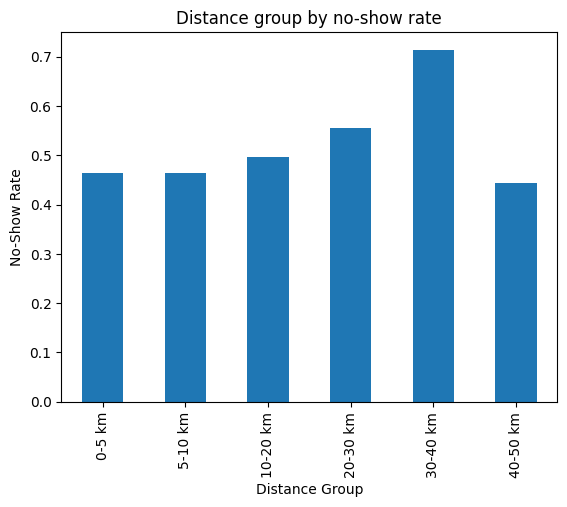

In [59]:
no_show_rate.plot(kind='bar', ylabel='No-Show Rate', xlabel='Distance Group')
plt.title("Distance group by no-show rate")
plt.show()

### No‑show rates generally increase with distance, suggesting transport barriers. However, the apparent dip in the farthest group is due to low sample size, not improved attendance.

## ANALYSIS

### Appointment Type Distribution
#### Most common appointment type is for general consultation while the least one is for diagnostic test.

### Appointment Time Distribution
#### Morning and afternoon appointments are the most common and are almost equally likely. Evening appointments are not as likely. 
##### Scheduling patterns lean toward daytime slots, which may influence attendance trends and resource allocation.

### Appointment Day Distribution
#### Appointments are booked almost equally across all days of the week. This indicates that day of week does not influence attendance outcomes.
##### Clinic scheduling is balanced across the week, so interventions to reduce no‑shows should focus on other factors rather than rescheduling by day.

In [62]:
(df["reminder_sent"] == "Yes").sum()/len(df)*100

np.float64(72.68)

### Reminders Sent
#### 73% of patients recieved a reminder.
##### Reminder systems are widely used, but analyzing their effectiveness is crucial to measure impact.

### Reminder Channels
#### SMS is the most used method channel for reminders.
##### The clinic relies heavily on SMS for reminders, which suggests that optimizing SMS campaigns could have the greatest impact on reducing no‑shows.

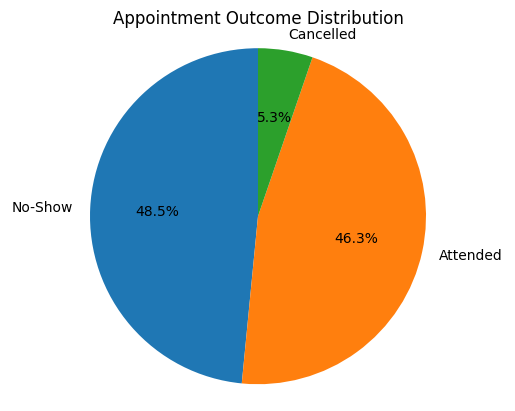

In [29]:
plt.pie(count2, labels = labels2, autopct='%1.1f%%', startangle=90)
plt.title("Appointment Outcome Distribution")
plt.axis('equal') 
plt.show()

### Overall Appointment Outcomes
#### 49% of patients were no-show while 46% did attend the appointment. Therefore patients booked for an appointment are almost equally likely to attend or miss their appointments.
#####  Attendance is highly unpredictable, and interventions are critical to improve reliability.

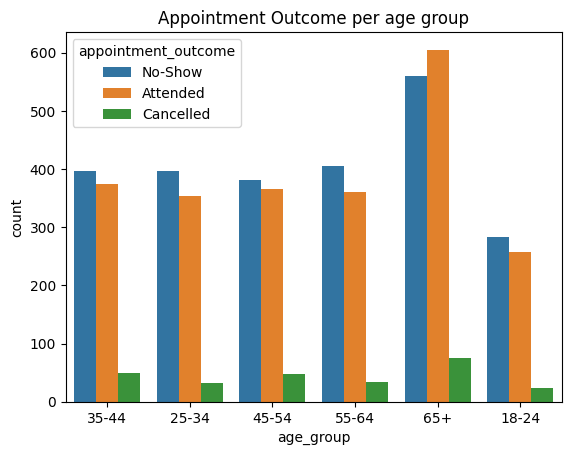

In [66]:
sns.countplot(x= df.age_group, hue= df.appointment_outcome)
plt.title("Appointment Outcome per age group")
plt.show()

###  Attendance by Age Group
#### No‑show numbers are higher than attendance across all age groups except for patients aged 65+. Seniors not only show the highest attendance rate but also represent the largest patient group, while the 18–24 group has the fewest patients.
#####  Seniors may attend more consistently due to higher health needs and fewer competing responsibilities, while younger patients are healthier and busier, making them more prone to missing appointments.

### Appointment outcomes are evenly distributed across days of the week and times of day, suggesting these factors do not significantly influence attendance.

<Axes: xlabel='appointment_outcome', ylabel='previous_no_shows'>

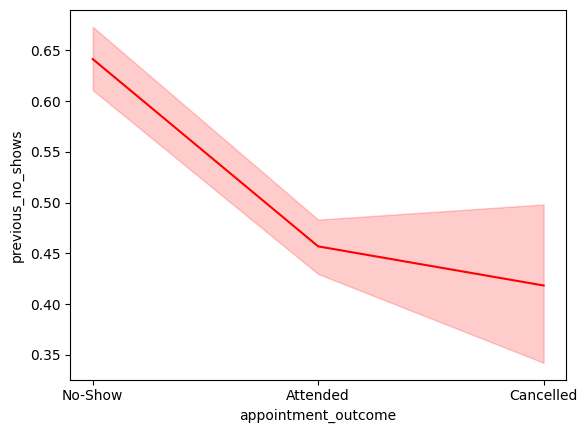

In [34]:
sns.lineplot(x= df.appointment_outcome, y= df.previous_no_shows, color = "red")

### Attendance by previous no-shows
#### Patients who are currently marked as No‑Show have a higher average number of past no‑shows compared to those who attended or cancelled.
##### Patients with a history of missed appointments are more likely to no‑show again. This highlights the importance of tracking patient history and targeting interventions for repeat offenders.

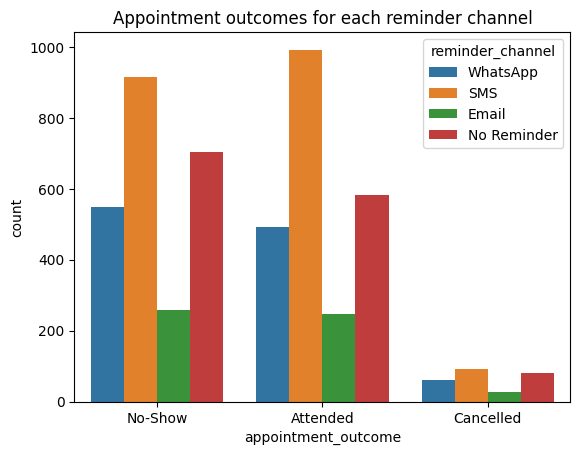

In [68]:
sns.countplot(x= df.appointment_outcome, hue= df.reminder_channel)
plt.title("Appointment outcomes for each reminder channel")
plt.show()

### Attendance by reminder channel
#### SMS dominates as the reminder channel, with the highest counts for both attended and no‑show outcomes. Other channels are much smaller.
##### SMS is the most used reminder channel, covering the majority of patients. Optimizing SMS reminders could have the greatest impact on reducing no‑shows.

### Waiting time averages are consistent across outcomes (~25 minutes), suggesting waiting time does not influence attendance.